In [103]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def report_metrics(y_true, y_pred, y_prob=None, label="", average="weighted"):
    """
    Report classification metrics for a multiclass classifier.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        y_prob: Predicted probabilities for all classes (shape: n_samples x n_classes, needed for AUC)
        label: Optional label for the report (e.g. "Train", "Test")
        average: Averaging strategy for precision/recall/f1 ("weighted", "macro", "micro")
    """
    error    = 1 - accuracy_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    prec     = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec      = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1       = f1_score(y_true, y_pred, average=average, zero_division=0)

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average=average)
    else:
        auc = "N/A (provide y_prob)"

    header = f"--- {label} Metrics ({average}) ---" if label else f"--- Metrics ({average}) ---"
    print(header)
    print(f"  Error:     {error:.4f}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}" if isinstance(auc, float) else f"  AUC:       {auc}")
    print()

In [94]:
print("Loading MLB pitch data from Kaggle...")
pitch_df = pd.read_csv('./2019_pitches.csv')
pitch_df

Loading MLB pitch data from Kaggle...


,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,event_num,b_score,ab_id,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b
0,0.00,2.15,88.8,80.7,placeholder,placeholder,22.8,4.8,24.0,-8.47,...,5,0.0,2.019000e+09,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.34,2.31,89.9,81.8,placeholder,placeholder,22.8,3.6,24.0,-7.10,...,8,0.0,2.019000e+09,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.05,2.03,85.7,79.6,placeholder,placeholder,9.6,6.0,24.0,3.65,...,9,0.0,2.019000e+09,0.0,0.0,1.0,2.0,0.0,0.0,0.0
3,0.49,0.92,85.4,78.5,placeholder,placeholder,24.0,7.2,24.0,-13.77,...,10,0.0,2.019000e+09,0.0,1.0,1.0,3.0,0.0,0.0,0.0
4,-0.13,1.11,84.6,77.6,placeholder,placeholder,26.4,8.4,24.0,-15.99,...,11,0.0,2.019000e+09,1.0,1.0,1.0,4.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728785,0.30,1.99,95.8,87.3,placeholder,placeholder,40.8,3.6,24.0,-13.45,...,500,1.0,2.019185e+09,2.0,0.0,1.0,4.0,0.0,0.0,0.0
728786,1.00,-0.38,87.2,80.3,placeholder,placeholder,7.2,7.2,24.0,-5.16,...,503,1.0,2.019185e+09,0.0,0.0,2.0,1.0,0.0,0.0,0.0
728787,0.36,2.02,95.0,86.6,placeholder,placeholder,33.6,3.6,24.0,-10.91,...,504,1.0,2.019185e+09,1.0,0.0,2.0,2.0,0.0,0.0,0.0
728788,-0.26,2.60,84.0,75.3,placeholder,placeholder,2.4,8.4,24.0,-2.69,...,505,1.0,2.019185e+09,1.0,0.0,2.0,3.0,0.0,0.0,0.0


In [95]:
print("All Features:")
list(pitch_df.columns)

All Features:


['px',
 'pz',
 'start_speed',
 'end_speed',
 'spin_rate',
 'spin_dir',
 'break_angle',
 'break_length',
 'break_y',
 'ax',
 'ay',
 'az',
 'sz_bot',
 'sz_top',
 'type_confidence',
 'vx0',
 'vy0',
 'vz0',
 'x',
 'x0',
 'y',
 'y0',
 'z0',
 'pfx_x',
 'pfx_z',
 'nasty',
 'zone',
 'code',
 'type',
 'pitch_type',
 'event_num',
 'b_score',
 'ab_id',
 'b_count',
 's_count',
 'outs',
 'pitch_num',
 'on_1b',
 'on_2b',
 'on_3b']

In [96]:
# B = Ball, S = Swinging Strike, F = Foul, X = In Play Out, D = In play no out, C = Called Strike
main_outcomes = ['B', 'S', 'F', 'X', 'D', 'C']

# filter to only main outcome types
pitch_df = pitch_df[pitch_df['code'].isin(main_outcomes)].copy()
pitch_df

,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,event_num,b_score,ab_id,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b
0,0.00,2.15,88.8,80.7,placeholder,placeholder,22.8,4.8,24.0,-8.47,...,5,0.0,2.019000e+09,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.34,2.31,89.9,81.8,placeholder,placeholder,22.8,3.6,24.0,-7.10,...,8,0.0,2.019000e+09,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.05,2.03,85.7,79.6,placeholder,placeholder,9.6,6.0,24.0,3.65,...,9,0.0,2.019000e+09,0.0,0.0,1.0,2.0,0.0,0.0,0.0
3,0.49,0.92,85.4,78.5,placeholder,placeholder,24.0,7.2,24.0,-13.77,...,10,0.0,2.019000e+09,0.0,1.0,1.0,3.0,0.0,0.0,0.0
4,-0.13,1.11,84.6,77.6,placeholder,placeholder,26.4,8.4,24.0,-15.99,...,11,0.0,2.019000e+09,1.0,1.0,1.0,4.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728785,0.30,1.99,95.8,87.3,placeholder,placeholder,40.8,3.6,24.0,-13.45,...,500,1.0,2.019185e+09,2.0,0.0,1.0,4.0,0.0,0.0,0.0
728786,1.00,-0.38,87.2,80.3,placeholder,placeholder,7.2,7.2,24.0,-5.16,...,503,1.0,2.019185e+09,0.0,0.0,2.0,1.0,0.0,0.0,0.0
728787,0.36,2.02,95.0,86.6,placeholder,placeholder,33.6,3.6,24.0,-10.91,...,504,1.0,2.019185e+09,1.0,0.0,2.0,2.0,0.0,0.0,0.0
728788,-0.26,2.60,84.0,75.3,placeholder,placeholder,2.4,8.4,24.0,-2.69,...,505,1.0,2.019185e+09,1.0,0.0,2.0,3.0,0.0,0.0,0.0


In [97]:
# Initial list of features:
features = ['px', 'pz', 'sz_bot', 'sz_top', 'start_speed', 'pfx_x', 'pfx_z', 'b_count', 's_count', 'outs']

# Encode pitch type (changeup, Fastball, etc) into integers
pitch_type_encoder = LabelEncoder()

# If Pitch type = NA, fill with Fastball code (default pitch)
pitch_df['pitch_type_enc'] = pitch_type_encoder.fit_transform(pitch_df['pitch_type'].fillna('FF'))
features.append('pitch_type_enc')

# Encode outcomes (# B = Ball, S = Swinging Strike, F = Foul, X = In Play Out, D = In play no out, C = Called Strike)
outcome_encoder = LabelEncoder()
pitch_df['outcome_enc'] = outcome_encoder.fit_transform(pitch_df['type'])
outcome_labels = outcome_encoder.classes_

# for missing values, fill with the median value of non na values in column
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(pitch_df[features]), columns=features)
y = pitch_df['outcome_enc']

X

,px,pz,sz_bot,sz_top,start_speed,pfx_x,pfx_z,b_count,s_count,outs,pitch_type_enc
0,0.00,2.15,1.70,3.36,88.8,-5.07,9.98,0.0,0.0,0.0,4.0
1,0.34,2.31,1.80,3.55,89.9,-4.14,11.18,0.0,0.0,1.0,4.0
2,-0.05,2.03,1.59,3.55,85.7,2.30,5.99,0.0,0.0,1.0,11.0
3,0.49,0.92,1.74,3.55,85.4,-8.87,4.14,0.0,1.0,1.0,0.0
4,-0.13,1.11,1.83,3.59,84.6,-10.51,2.51,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
675635,0.30,1.99,1.65,3.50,95.8,-6.90,10.64,2.0,0.0,1.0,4.0
675636,1.00,-0.38,1.60,3.31,87.2,-3.20,3.00,0.0,0.0,2.0,11.0
675637,0.36,2.02,1.56,3.39,95.0,-5.68,10.65,1.0,0.0,2.0,4.0
675638,-0.26,2.60,1.60,3.31,84.0,-1.84,1.31,1.0,0.0,2.0,11.0


In [98]:
# split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [99]:
from sklearn.ensemble import GradientBoostingClassifier

In [100]:

gbc = GradientBoostingClassifier(
    max_depth=5,
    learning_rate=.1, 
    n_estimators=100,
    random_state=42    
)

gbc.fit(X_train, y_train)

y_train_pred = gbc.predict(X_train)
y_test_pred = gbc.predict(X_test)
y_train_prob = gbc.predict_proba(X_train) 
y_test_prob = gbc.predict_proba(X_test) 


report_metrics(y_train, y_train_pred, y_train_prob, label="Train")
report_metrics(y_test,  y_test_pred, y_test_prob, label="Test")



--- Train Metrics (weighted) ---
  Error:     0.4368
  Accuracy:  0.5632
  Precision: 0.5476
  Recall:    0.5632
  F1 Score:  0.5054
  AUC:       0.8478

--- Test Metrics (weighted) ---
  Error:     0.4410
  Accuracy:  0.5590
  Precision: 0.4987
  Recall:    0.5590
  F1 Score:  0.5004
  AUC:       0.8432



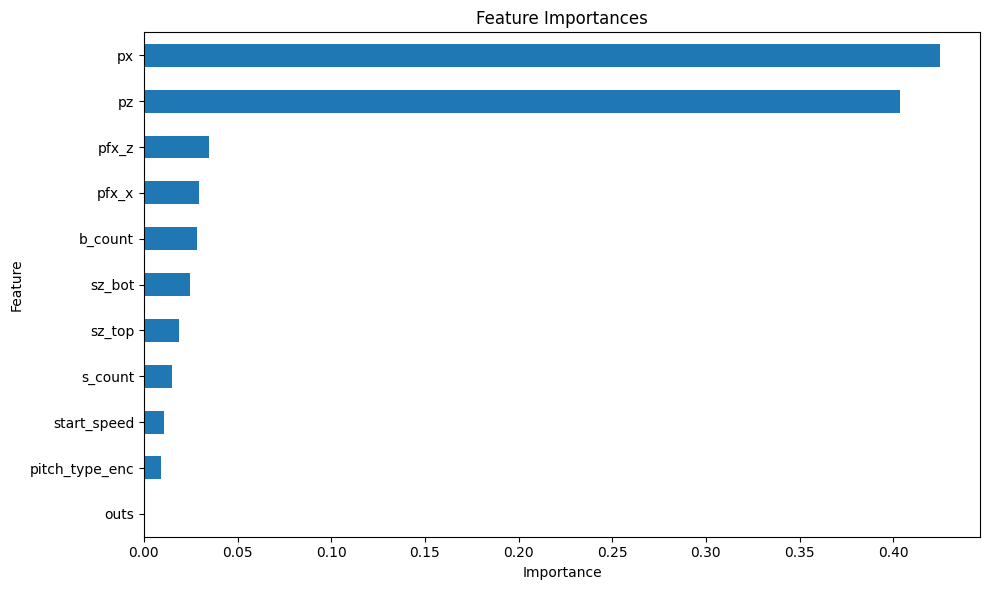

In [104]:
importances = gbc.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, max(6, len(feat_imp) * 0.3)))
feat_imp.plot(kind='barh')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()